In [112]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
test_data = pd.read_csv("test_data.csv")
test_data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
1,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
2,38,Self-emp-not-inc,164526,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,0,2824,45,United-States,>50K
3,45,Private,172822,11th,7,Divorced,Transport-moving,Not-in-family,White,Male,0,2824,76,United-States,>50K
4,33,Private,228696,1st-4th,2,Married-civ-spouse,Craft-repair,Not-in-family,White,Male,0,2603,32,Mexico,<=50K


In [114]:
train_data= pd.read_csv("train_data.csv")
train_data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,48,Private,191858,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
1,54,Private,145419,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,1672,50,United-States,<=50K
2,43,Private,182757,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K
3,32,Private,191777,Assoc-voc,11,Never-married,Exec-managerial,Not-in-family,Black,Female,0,0,35,England,<=50K
4,43,State-gov,206139,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,50,United-States,>50K


In [115]:
def clean_data(train_data, test_data):
    #To do: clean the dataset

    #replace “?” values(occupation, work class, native country)
    imputer = SimpleImputer(missing_values='?', strategy='most_frequent')
    cols_to_impute = ['workclass', 'occupation', 'native.country']
    train_data[cols_to_impute] = imputer.fit_transform(train_data[cols_to_impute])
    test_data[cols_to_impute] = imputer.transform(test_data[cols_to_impute])
    
    #Replace strange values/outliers - fix capital gain
    train_data["capital.gain"] = train_data["capital.gain"].replace(99999.0, np.mean(train_data["capital.gain"]))
    test_data["capital.gain"] = test_data["capital.gain"].replace(99999.0, np.mean(test_data["capital.gain"]))  
    
    #Simplify Column Names
    train_data.race = train_data.race.replace(["Black", "Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"], "Other")
    test_data.race = test_data.race.replace(["Black", "Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other"], "Other")
    
    train_data.education = train_data.education.replace(["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th"], "School")
    test_data.education = test_data.education.replace(["Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th"], "School")

    #Drop uneccessary columns
    train_data = train_data.drop(columns= ['education.num','fnlwgt', 'native.country'])
    test_data = test_data.drop(columns= ['education.num','fnlwgt', 'native.country'])

    #convery to binary values
    train_data['income'] = train_data['income'].map({'<=50K': 0, '>50K': 1})
    test_data['income'] = test_data['income'].map({'<=50K': 0, '>50K': 1})

    #Save into new cleaned files
    train_data.to_csv('cleaned_train_data.csv', index=False)
    test_data.to_csv('cleaned_test_data.csv', index=False)
    
    return 

In [193]:
def plot_numeric_feature_correlation(train_data):
    #To do: plot the correlation matrix for numerical features
    
    train_data['income_num'] = train_data['income'].map({
    '<=50K': 0,
    '>50K': 1
    })

    correlation_matrix = train_data[
        ['age', 'capital.gain', 'capital.loss', 'hours.per.week', 'income_num']
    ].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".3f", cbar=True, cmap='PuRd')
    plt.title("Correlation Heatmap of Different Features")
    plt.show()


In [194]:
def plot_histogram(train_data):
    # To do: plot histograms for all features
    
    columns_to_plot = ['age', 'capital.gain', 'capital.loss', 'hours.per.week', "education"]
    
    # First subplot: 3 plots (first 3 columns)
    fig1, axes1 = plt.subplots(1, 3, figsize=(20, 5))  # 1 row, 3 columns
    for i, column in enumerate(columns_to_plot[:3]):  # First 3 columns
        sns.histplot(data=train_data, x=column, hue="income", multiple="dodge", bins=20, kde=False, palette=["blue", "red"], stat="count", ax=axes1[i])
        axes1[i].set_title(f'Histogram of {column} by Income')
        axes1[i].set_xlabel(column)
        axes1[i].set_ylabel('Number of Samples')
        axes1[i].tick_params(axis='x', rotation=45)
        axes1[i].legend(title="Income", labels=["<=50K", ">50K"])
    plt.tight_layout()
    plt.show()
    
    # Second subplot: 2 plots (last 2 columns)
    fig2, axes2 = plt.subplots(1, 2, figsize=(18, 5))  # 1 row, 2 columns
    for i, column in enumerate(columns_to_plot[3:]):  # Last 2 columns
        sns.histplot(data=train_data, x=column, hue="income", multiple="dodge", bins=20, kde=False, palette=["blue", "red"], stat="count", ax=axes2[i])
        axes2[i].set_title(f'Histogram of {column} by Income')
        axes2[i].set_xlabel(column)
        axes2[i].set_ylabel('Number of Samples')
        axes2[i].tick_params(axis='x', rotation=45)
        axes2[i].legend(title="Income", labels=["<=50K", ">50K"])
    plt.tight_layout()
    plt.show()
    
    return

In [195]:
# Load data
train_data = pd.read_csv('train_data.csv')
test_data = pd.read_csv('test_data.csv')

In [196]:
clean_data(train_data, test_data)

In [197]:
# Load in Cleaned Data
clean_train_data = pd.read_csv('cleaned_train_data.csv')
clean_train_data.head()

,age,workclass,education,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,48,Private,Some-college,Married-civ-spouse,Craft-repair,Husband,White,Male,0.0,0,40,0
1,54,Private,HS-grad,Married-civ-spouse,Sales,Husband,White,Male,0.0,1672,50,0
2,43,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,0.0,0,40,1
3,32,Private,Assoc-voc,Never-married,Exec-managerial,Not-in-family,Other,Female,0.0,0,35,0
4,43,State-gov,Bachelors,Married-civ-spouse,Adm-clerical,Husband,White,Male,0.0,0,50,1


In [198]:
clean_test_data = pd.read_csv('cleaned_test_data.csv')
clean_test_data.head()

,age,workclass,education,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,34,Private,HS-grad,Divorced,Other-service,Unmarried,White,Female,0.0,3770,45,0
1,68,Federal-gov,HS-grad,Divorced,Prof-specialty,Not-in-family,White,Female,0.0,3683,40,0
2,38,Self-emp-not-inc,Prof-school,Never-married,Prof-specialty,Not-in-family,White,Male,0.0,2824,45,1
3,45,Private,School,Divorced,Transport-moving,Not-in-family,White,Male,0.0,2824,76,1
4,33,Private,School,Married-civ-spouse,Craft-repair,Not-in-family,White,Male,0.0,2603,32,0


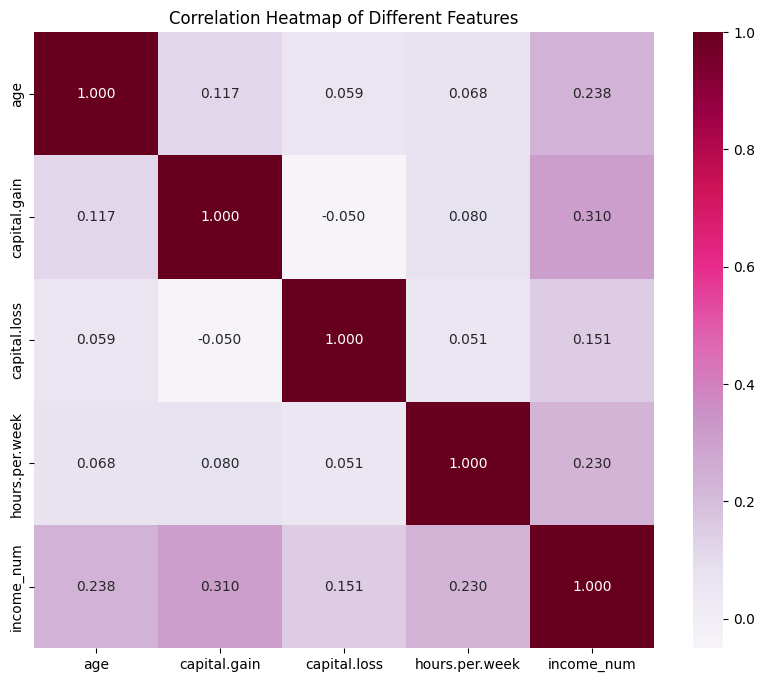

In [199]:
plot_numeric_feature_correlation(train_data)

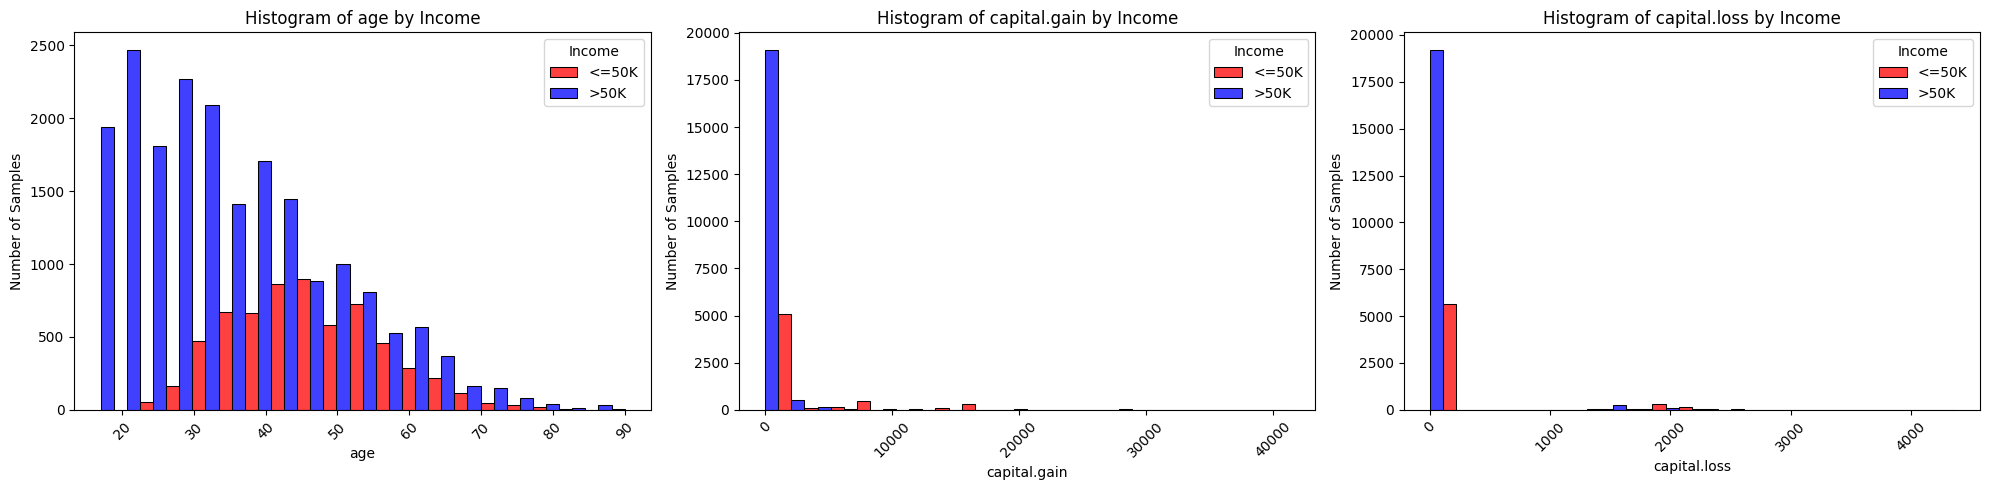

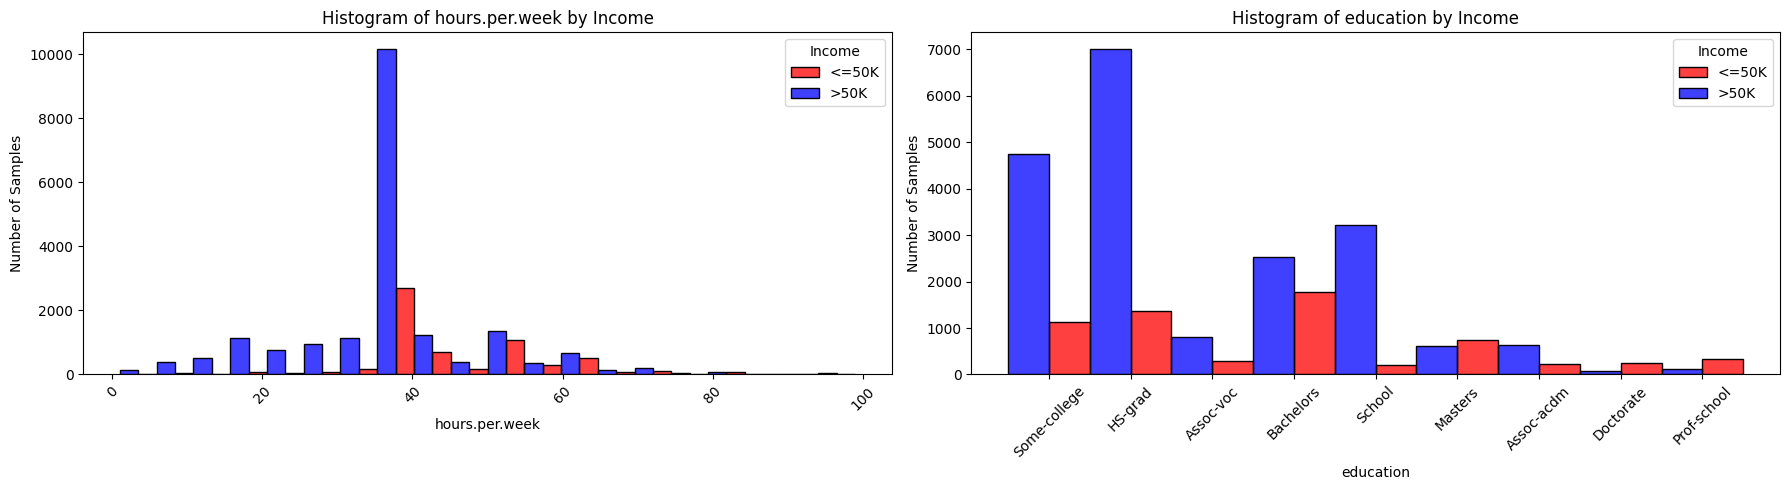

In [200]:
plot_histogram(train_data)